# **LSTM 框架下的情感消融实验**

Notebook 02 使用 Random Forest 验证了 FinBERT 情感特征在高推文覆盖率下的增量贡献。但 Random Forest 将每个 stock-day 视为独立样本，无法建模时序依赖关系。本 notebook 在 **LSTM 框架**下重复消融实验，验证：**在能建模时序的模型中，情感特征是否仍有增量贡献？**

## **实验设计**

这是一个**独立的 LSTM 框架内消融实验**，而非 RF vs LSTM 的模型对比。模型架构和超参数恒定，**唯一变量是有无情感特征**。

| 变体 | 输入特征 | 维度 | 说明 |
|------|---------|------|------|
| **OHLCV-Only** | ret, open, high, low, vol_pct | 5 | 价格序列 baseline |
| **OHLCV+Sent** | OHLCV + positive_mean, negative_mean, tweet_count | 8 | 加入精简情感 |

与 Notebook 02 的关键区别：

- **输入形式不同**：LSTM 喂原始 OHLCV 序列（转为收益率），不使用手工技术指标（MA、RSI、MACD 等）
- **情感占比更高**：3/8 = 37.5%（vs RF 的 3/13 = 23%），对情感更敏感

| 实验 | 股票数 | 推文覆盖率 | 研究问题 |
|------|--------|-----------|----------|
| **实验 A** | 高覆盖子集 | 高 | 在数据充分的理想条件下，情感能否提升 LSTM？ |
| **实验 B** | 87 只（全部） | ~45% | 覆盖率下降时，情感是否仍有效？ |

In [15]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, matthews_corrcoef, roc_auc_score,
                             ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# Paths
PRICE_DIR = os.path.join('..', 'Data', 'price', 'preprocessed')
CACHE_DIR = os.path.join('..', 'cache')
OUTPUT_DIR = os.path.join('..', 'output_lstm')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

# Hyperparameters
SEQ_LEN = 20
HIDDEN_SIZE = 32
NUM_LAYERS = 1
DROPOUT = 0.3
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 50
PATIENCE = 7

Device: mps


---
## **公共模块：数据加载、模型定义**

In [2]:
def load_price_data(price_dir, stocks=None):
    """Load preprocessed price data (same as Notebook 02)."""
    cols = ['date', 'movement_pct', 'open', 'high', 'low', 'close', 'volume']
    all_prices = []
    for fname in sorted(os.listdir(price_dir)):
        if not fname.endswith('.txt'): continue
        stock = fname.replace('.txt', '')
        if stocks is not None and stock not in stocks: continue
        df = pd.read_csv(os.path.join(price_dir, fname), sep='\t',
                         header=None, names=cols)
        df['stock'] = stock
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        all_prices.append(df)
    return pd.concat(all_prices, ignore_index=True)


SENT_SLIM = ['positive_mean', 'negative_mean', 'tweet_count']

### **OHLCV 历史股价数据**

预处理数据中 `movement_pct`、`open`、`high`、`low` 已是相对前收盘的百分比变化（天然平稳）。`close` 列是绝对美元差值（跨股票不可比），丢弃。`volume` 是原始绝对值，转为百分比变化。

| LSTM 特征 | 来源 | 含义 |
|-----------|------|------|
| `ret` | `movement_pct` | 日收益率 |
| `open_ret` | `open` | 开盘价相对前收盘% |
| `high_ret` | `high` | 最高价相对前收盘% |
| `low_ret` | `low` | 最低价相对前收盘% |
| `vol_pct` | `volume.pct_change()` | 成交量变化率 |

In [3]:
def prepare_ohlcv_features(df):
    """Convert preprocessed price data to 5 stationary OHLCV features."""
    result = []
    for stock, g in df.groupby('stock'):
        g = g.copy().sort_values('date')
        g['ret'] = g['movement_pct']
        g['open_ret'] = g['open']
        g['high_ret'] = g['high']
        g['low_ret'] = g['low']
        g['vol_pct'] = g['volume'].pct_change()
        result.append(g)
    out = pd.concat(result, ignore_index=True)
    out['vol_pct'] = out['vol_pct'].replace([np.inf, -np.inf], np.nan)
    return out


OHLCV_COLS = ['ret', 'open_ret', 'high_ret', 'low_ret', 'vol_pct']

In [4]:
def prepare_lstm_dataset(price_dir, cache_dir, stocks=None):
    """
    Pipeline: load price -> OHLCV features -> merge sentiment
    -> date filter -> target -> per-stock 80/20 split.
    """
    prices = load_price_data(price_dir, stocks)
    prices = prepare_ohlcv_features(prices)
    prices = prices.dropna(subset=OHLCV_COLS).reset_index(drop=True)

    # Load and merge sentiment
    sent = pd.read_pickle(os.path.join(cache_dir, 'daily_sentiment.pkl'))
    sent['date'] = pd.to_datetime(sent['date'])
    df = prices.merge(sent[['stock', 'date'] + SENT_SLIM],
                      on=['stock', 'date'], how='left')

    # Fill missing sentiment
    defaults = {'positive_mean': 1/3, 'negative_mean': 1/3, 'tweet_count': 0}
    df[SENT_SLIM] = df[SENT_SLIM].fillna(defaults)

    # Date filter
    df = df[(df['date'] >= '2014-01-01') & (df['date'] <= '2015-12-31')]

    # Target: next-day movement (same as Notebook 02)
    df['target'] = (df.groupby('stock')['movement_pct'].shift(-1) > 0).astype(float)
    df = df.dropna(subset=['target']).reset_index(drop=True)
    df['target'] = df['target'].astype(int)

    # Per-stock 80/20 time-series split
    train_list, test_list = [], []
    for stock, group in df.groupby('stock'):
        n = len(group)
        split_idx = int(n * 0.8)
        train_list.append(group.iloc[:split_idx])
        test_list.append(group.iloc[split_idx:])

    train_df = pd.concat(train_list, ignore_index=True)
    test_df = pd.concat(test_list, ignore_index=True)

    return df, train_df, test_df

### **PyTorch Dataset**

LSTM 需要 3D 输入 `(batch, seq_len, features)`。对每只股票的时间序列，用长度为 20 的滑动窗口生成样本。**序列不跨越股票边界。**

StandardScaler 在训练集上 fit，验证集和测试集只做 transform，防止数据泄露。

In [5]:
class StockSequenceDataset(Dataset):
    """Sliding-window sequences per stock, with StandardScaler."""

    def __init__(self, df, feature_cols, seq_len=20, scaler=None):
        self.seq_len = seq_len
        self.sequences = []
        self.targets = []

        # Scale features
        if scaler is None:
            self.scaler = StandardScaler()
            scaled_vals = self.scaler.fit_transform(df[feature_cols])
        else:
            self.scaler = scaler
            scaled_vals = self.scaler.transform(df[feature_cols])

        df_scaled = df.copy()
        df_scaled[feature_cols] = scaled_vals

        # Build sequences per stock (no cross-stock windows)
        for stock, group in df_scaled.groupby('stock'):
            group = group.sort_values('date').reset_index(drop=True)
            features = group[feature_cols].values
            targets = group['target'].values

            for i in range(seq_len, len(group)):
                self.sequences.append(features[i - seq_len : i])
                self.targets.append(targets[i])

        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.targets = np.array(self.targets, dtype=np.int64)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (torch.tensor(self.sequences[idx]),
                torch.tensor(self.targets[idx]))

### **LSTM （Long Short-Term Memory）**

In [6]:
class StockLSTM(nn.Module):
    """Single-layer LSTM for binary stock movement prediction."""

    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        out = self.dropout(h_n[-1])
        return self.fc(out).squeeze(-1)

### **Train and Evaluation**

In [7]:
def train_model(model, train_loader, val_loader, device,
                lr=1e-3, epochs=50, patience=7):
    """Train LSTM with early stopping on validation loss."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.float().to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.float().to(device)
                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1:3d}  train={train_loss:.4f}  '
                  f'val={val_loss:.4f}  patience={patience_counter}/{patience}')

        if patience_counter >= patience:
            print(f'  Early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    return model, history

In [8]:
def evaluate_lstm(model, data_loader, device):
    """Evaluate LSTM, return metrics + predictions."""
    model.eval()
    all_logits, all_targets = [], []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            all_logits.append(logits.cpu().numpy())
            all_targets.append(y_batch.numpy())

    logits = np.concatenate(all_logits)
    y_true = np.concatenate(all_targets)
    y_prob = 1 / (1 + np.exp(-logits))
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'MCC':       matthews_corrcoef(y_true, y_pred),
        'AUC':       roc_auc_score(y_true, y_prob),
    }
    return metrics, y_pred, y_prob, y_true

### **Experiment Runner**

In [9]:
def run_lstm_experiment(train_df, test_df, feature_sets, device,
                        seq_len=SEQ_LEN, hidden_size=HIDDEN_SIZE,
                        batch_size=BATCH_SIZE, lr=LR, epochs=EPOCHS,
                        patience=PATIENCE, seed=SEED):
    """Run LSTM ablation across feature sets."""
    results = []
    models_dict = {}

    for feat_label, feat_cols in feature_sets.items():
        print(f'\n{"="*50}')
        print(f'{feat_label}  (dim={len(feat_cols)})')
        print(f'{"="*50}')

        # Reset seed for each run
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)

        # Train/val split: per-stock last 15% of train as validation
        tr_list, val_list = [], []
        for stock, group in train_df.groupby('stock'):
            n = len(group)
            val_start = int(n * 0.85)
            tr_list.append(group.iloc[:val_start])
            val_list.append(group.iloc[val_start:])
        tr_sub = pd.concat(tr_list, ignore_index=True)
        val_sub = pd.concat(val_list, ignore_index=True)

        # Build datasets (scaler fit on tr_sub only)
        train_ds = StockSequenceDataset(tr_sub, feat_cols, seq_len)
        val_ds = StockSequenceDataset(val_sub, feat_cols, seq_len,
                                      scaler=train_ds.scaler)
        test_ds = StockSequenceDataset(test_df, feat_cols, seq_len,
                                       scaler=train_ds.scaler)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

        print(f'  Sequences: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}')

        # Build and train
        model = StockLSTM(input_size=len(feat_cols),
                          hidden_size=hidden_size,
                          dropout=DROPOUT).to(device)
        model, history = train_model(model, train_loader, val_loader, device,
                                     lr=lr, epochs=epochs, patience=patience)

        # Evaluate on test
        metrics, y_pred, y_prob, y_true = evaluate_lstm(model, test_loader, device)
        metrics['Features'] = feat_label
        results.append(metrics)
        models_dict[feat_label] = {
            'model': model, 'history': history,
            'y_pred': y_pred, 'y_prob': y_prob, 'y_true': y_true,
        }

        print(f'  Test: Acc={metrics["Accuracy"]:.4f}  F1={metrics["F1"]:.4f}  '
              f'MCC={metrics["MCC"]:.4f}  AUC={metrics["AUC"]:.4f}')

    return pd.DataFrame(results), models_dict

### **Visulization**

In [10]:
def plot_training_curves(models_dict, title, save_path=None):
    """Plot train/val loss curves side by side."""
    n = len(models_dict)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (label, info) in zip(axes, models_dict.items()):
        ax.plot(info['history']['train_loss'], label='Train')
        ax.plot(info['history']['val_loss'], label='Val')
        ax.set_title(label)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('BCE Loss')
        ax.legend()
        ax.grid(alpha=0.3)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def plot_confusion_matrices(models_dict, title, save_path=None):
    """Plot confusion matrices side by side."""
    n = len(models_dict)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (label, info) in zip(axes, models_dict.items()):
        ConfusionMatrixDisplay.from_predictions(
            info['y_true'], info['y_pred'],
            display_labels=['Down', 'Up'], ax=ax, cmap='Blues')
        ax.set_title(label)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

---
## **股票选择**

Notebook 02 的实验 A 固定使用 4 只股票（AAPL, AMZN, BABA, GOOG），对 LSTM 来说样本太少。改为按推文覆盖率阈值筛选，平衡高覆盖率和足够的训练样本量。

In [11]:
def select_high_coverage_stocks(price_dir, cache_dir, min_coverage=0.70):
    """Select stocks with tweet coverage >= threshold in 2014-2015."""
    prices = load_price_data(price_dir)
    prices = prices[(prices['date'] >= '2014-01-01') & (prices['date'] <= '2015-12-31')]

    sent = pd.read_pickle(os.path.join(cache_dir, 'daily_sentiment.pkl'))
    sent['date'] = pd.to_datetime(sent['date'])

    merged = prices[['stock', 'date']].merge(
        sent[['stock', 'date', 'tweet_count']],
        on=['stock', 'date'], how='left')
    merged['has_tweet'] = merged['tweet_count'].notna()

    coverage = merged.groupby('stock')['has_tweet'].mean().sort_values(ascending=False)
    selected = coverage[coverage >= min_coverage].index.tolist()

    print(f'Stocks with >= {min_coverage:.0%} tweet coverage: {len(selected)}')
    print(coverage[coverage >= min_coverage].to_string())
    return selected, coverage


high_cov_stocks, coverage_all = select_high_coverage_stocks(PRICE_DIR, CACHE_DIR, 0.70)

Stocks with >= 70% tweet coverage: 25
stock
AAPL    0.952381
FB      0.948413
T       0.942460
GOOG    0.940476
AMZN    0.936508
MSFT    0.920635
BABA    0.904025
C       0.882937
D       0.880952
BAC     0.869048
PCLN    0.843254
JPM     0.833333
GE      0.821429
INTC    0.819444
XOM     0.773810
CSCO    0.763889
JNJ     0.744048
DIS     0.744048
CELG    0.732143
PFE     0.720238
WMT     0.716270
VZ      0.714286
MCD     0.710317
KO      0.710317
V       0.702381


---
## **实验 A: 高覆盖率股票**

使用推文覆盖率 >= 70% 的股票子集，在情感数据充分的理想条件下测试 LSTM 消融。

In [12]:
df_A, train_A, test_A = prepare_lstm_dataset(PRICE_DIR, CACHE_DIR, stocks=high_cov_stocks)

print(f'Stocks: {df_A["stock"].nunique()}')
print(f'Date:   {df_A["date"].min().date()} ~ {df_A["date"].max().date()}')
print(f'Train:  {len(train_A)},  Test: {len(test_A)}')
print(f'Sentiment coverage (train): {train_A["tweet_count"].gt(0).mean():.1%}')
print(f'Sentiment coverage (test):  {test_A["tweet_count"].gt(0).mean():.1%}')
print(f'Label (train): up={train_A["target"].sum()} ({train_A["target"].mean():.1%}), '
      f'down={(train_A["target"]==0).sum()} ({1-train_A["target"].mean():.1%})')
print(f'Label (test):  up={test_A["target"].sum()} ({test_A["target"].mean():.1%}), '
      f'down={(test_A["target"]==0).sum()} ({1-test_A["target"].mean():.1%})')

Stocks: 25
Date:   2014-01-02 ~ 2015-12-31
Train:  9929,  Test: 2489
Sentiment coverage (train): 81.3%
Sentiment coverage (test):  84.8%
Label (train): up=5081 (51.2%), down=4848 (48.8%)
Label (test):  up=1234 (49.6%), down=1255 (50.4%)


### A-1. Model Performance

In [16]:
LSTM_FEATURE_SETS = {
    'OHLCV-Only (5)':  OHLCV_COLS,
    'OHLCV+Sent (8)':  OHLCV_COLS + SENT_SLIM,
}

res_A, models_A = run_lstm_experiment(train_A, test_A, LSTM_FEATURE_SETS, device)

display_cols = ['Features', 'Accuracy', 'Precision', 'Recall', 'F1', 'MCC', 'AUC']
print('\n=== Experiment A: High-coverage stocks ===')
print(res_A[display_cols].to_string(index=False, float_format='{:.4f}'.format))


OHLCV-Only (5)  (dim=5)
  Sequences: train=7926, val=1003, test=1989
  Epoch   5  train=0.6908  val=0.6897  patience=0/7
  Epoch  10  train=0.6900  val=0.6890  patience=1/7
  Epoch  15  train=0.6881  val=0.6873  patience=1/7
  Epoch  20  train=0.6860  val=0.6896  patience=6/7
  Early stopping at epoch 21
  Test: Acc=0.5118  F1=0.5728  MCC=0.0191  AUC=0.5104

OHLCV+Sent (8)  (dim=8)
  Sequences: train=7926, val=1003, test=1989
  Epoch   5  train=0.6912  val=0.6910  patience=1/7
  Epoch  10  train=0.6880  val=0.6884  patience=0/7
  Epoch  15  train=0.6838  val=0.6889  patience=2/7
  Epoch  20  train=0.6776  val=0.6923  patience=7/7
  Early stopping at epoch 20
  Test: Acc=0.4947  F1=0.5198  MCC=-0.0123  AUC=0.4939

=== Experiment A: High-coverage stocks ===
      Features  Accuracy  Precision  Recall     F1     MCC    AUC
OHLCV-Only (5)    0.5118     0.5171  0.6420 0.5728  0.0191 0.5104
OHLCV+Sent (8)    0.4947     0.5042  0.5365 0.5198 -0.0123 0.4939


### A-2. Confusion Matrices

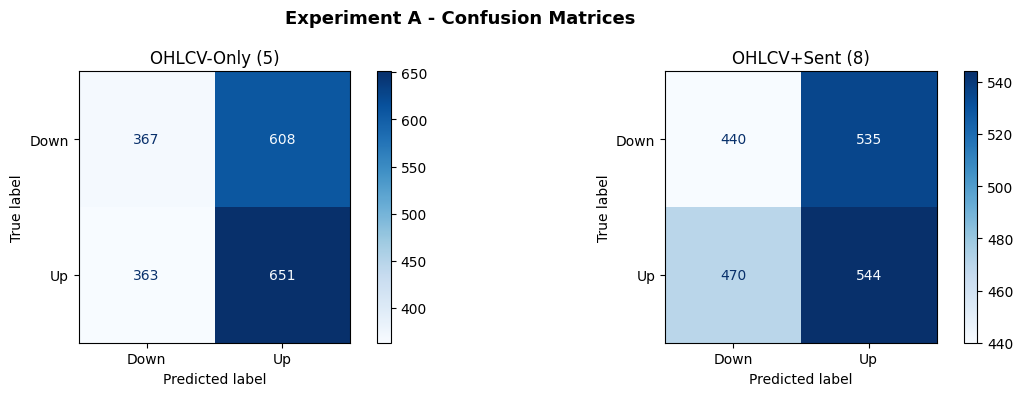

In [18]:
plot_confusion_matrices(models_A, 'Experiment A - Confusion Matrices',
                        os.path.join(OUTPUT_DIR, 'expA_confusion.png'))

### A-3. Conclusion

（运行后根据实际结果填写。）

---
## **实验 B: 全量股票**

将股票池扩展到全部 87 只股票，推文覆盖率降至 ~45%。约 55% 的 stock-day 情感特征由默认值填充。

In [19]:
df_B, train_B, test_B = prepare_lstm_dataset(PRICE_DIR, CACHE_DIR, stocks=None)

print(f'Stocks: {df_B["stock"].nunique()}')
print(f'Date:   {df_B["date"].min().date()} ~ {df_B["date"].max().date()}')
print(f'Train:  {len(train_B)},  Test: {len(test_B)}')
print(f'Sentiment coverage (train): {train_B["tweet_count"].gt(0).mean():.1%}')
print(f'Sentiment coverage (test):  {test_B["tweet_count"].gt(0).mean():.1%}')
print(f'Label (train): up={train_B["target"].sum()} ({train_B["target"].mean():.1%}), '
      f'down={(train_B["target"]==0).sum()} ({1-train_B["target"].mean():.1%})')
print(f'Label (test):  up={test_B["target"].sum()} ({test_B["target"].mean():.1%}), '
      f'down={(test_B["target"]==0).sum()} ({1-test_B["target"].mean():.1%})')

Stocks: 87
Date:   2014-01-02 ~ 2015-12-31
Train:  34684,  Test: 8693
Sentiment coverage (train): 44.6%
Sentiment coverage (test):  45.3%
Label (train): up=17788 (51.3%), down=16896 (48.7%)
Label (test):  up=4204 (48.4%), down=4489 (51.6%)


### B-1. Model Performance

In [20]:
res_B, models_B = run_lstm_experiment(train_B, test_B, LSTM_FEATURE_SETS, device)

print('\n=== Experiment B: 87 stocks ===')
print(res_B[display_cols].to_string(index=False, float_format='{:.4f}'.format))


OHLCV-Only (5)  (dim=5)
  Sequences: train=27694, val=3510, test=6953
  Epoch   5  train=0.6916  val=0.6925  patience=0/7
  Epoch  10  train=0.6900  val=0.6958  patience=4/7
  Early stopping at epoch 13
  Test: Acc=0.5136  F1=0.6274  MCC=0.0382  AUC=0.5347

OHLCV+Sent (8)  (dim=8)
  Sequences: train=27694, val=3510, test=6953
  Epoch   5  train=0.6914  val=0.6936  patience=1/7
  Epoch  10  train=0.6893  val=0.6976  patience=3/7
  Early stopping at epoch 14
  Test: Acc=0.5088  F1=0.5768  MCC=0.0203  AUC=0.5211

=== Experiment B: 87 stocks ===
      Features  Accuracy  Precision  Recall     F1    MCC    AUC
OHLCV-Only (5)    0.5136     0.5069  0.8228 0.6274 0.0382 0.5347
OHLCV+Sent (8)    0.5088     0.5049  0.6725 0.5768 0.0203 0.5211


### B-2. Confusion Matrices

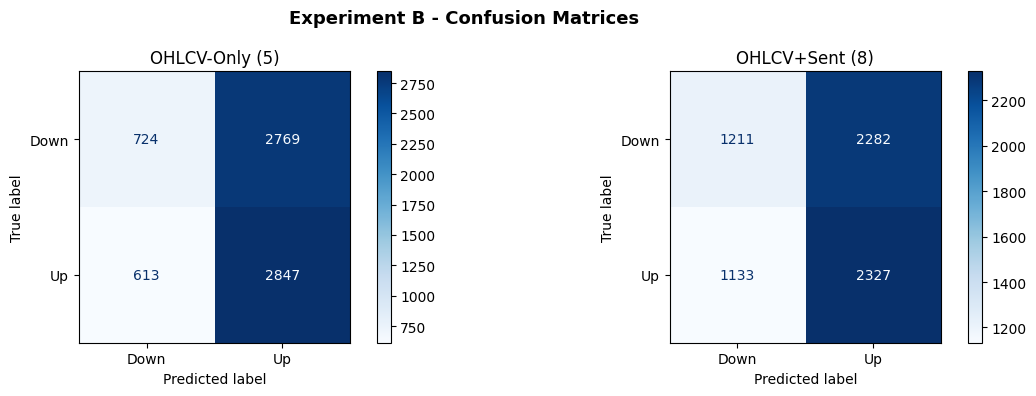

In [21]:
plot_confusion_matrices(models_B, 'Experiment B - Confusion Matrices',
                        os.path.join(OUTPUT_DIR, 'expB_confusion.png'))

### B-3. Conclusion

（运行后根据实际结果填写。）